In [187]:
from robot_vlp.config import INTERIM_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR, MODELS_DIR
import pickle
import numpy as np
import keras
import robot_vlp.data.preprocessing as p
import matplotlib.pyplot as plt
import robot_vlp.data_collection.communication as c

from robot_vlp.modeling.rnn import ang_loss_fn

import robot_vlp.data.odometer_path_navigation as pg
import robot_vlp.plots.model_performance_plotting as pp
import robot_vlp.modeling.rnn as rnn

%load_ext autoreload
%autoreload 2

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [430]:
dir = INTERIM_DATA_DIR / 'exp_vive_navigated_paths'

train_files = [

    'exp03_high_acc.csv',
    # 'exp03_low_acc.csv',


    # 'exp04_high_acc.csv',
    # 'exp04_low_acc.csv',
    # 'exp05_high_acc.csv',
    # 'exp05_low_acc.csv',

    ]
valid_files = [    
    'exp02_high_acc.csv',
    # 'exp02_low_acc.pkl',


]

test_files = [
    'exp01_high_acc.csv',
    # 'exp01_low_acc.pkl',


]

overlap = 0.99999
window_len = 40




In [431]:
def read_csv_to_train(file_list):
    X_lst = []
    y_lst = []
    m_lst = []

    for filename in file_list:
        file = dir / filename
        df = pd.read_csv(file)
        X_win, y_win, m_win = preprocess_df(df)
        X_lst.append(X_win)
        y_lst.append(y_win)
        m_lst.append(m_win)


    X = np.concatenate(X_lst, axis = 0)
    y = np.concatenate(y_lst, axis = 0)
    m = np.concatenate(m_lst, axis = 0)

    return X, y, m

In [432]:
X_train, y_train, _ = read_csv_to_train(train_files)
X_valid, y_valid, _ = read_csv_to_train(valid_files)

In [414]:
run_logdir = rnn.get_run_logdir()  
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',patience=100, restore_best_weights = True )
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint('exp_vive_nav.weights.h5',save_weights_only = True)

In [478]:
model = rnn.build_default_model('test')
# model = keras.models.load_model(MODELS_DIR / 'exp_vive_trained.keras',custom_objects={"ang_loss_fn": rnn.ang_loss_fn})


In [479]:
history = model.fit(
    x = X_train, 
    y = [y_train[:,[0,1]],  p.ang_to_vector(y_train[:,2], unit = 'degrees').numpy()],
    epochs = 2000,
    batch_size = 64,
    validation_data = (X_valid, [y_valid[:,[0,1]], p.ang_to_vector(y_valid[:,2], unit = 'degrees').numpy()]), 
    # callbacks = [tensorboard_cb, early_stopping_cb, checkpoint_cb]    
    )

Epoch 1/2000


/Users/tyrelglass/miniforge3/envs/robot-vlp/lib/python3.10/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_100']. Received: the structure of inputs=*
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - heading_loss: 9912.6934 - loss: 9929.4346 - pos_loss: 1.7744 - val_heading_loss: 9108.5850 - val_loss: 9136.0449 - val_pos_loss: 1.9168
Epoch 2/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - heading_loss: 10058.5059 - loss: 9954.1758 - pos_loss: 1.7774 - val_heading_loss: 9108.2559 - val_loss: 9134.5566 - val_pos_loss: 1.9223
Epoch 3/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - heading_loss: 9907.2578 - loss: 9966.7041 - pos_loss: 1.8044 - val_heading_loss: 9109.9414 - val_loss: 9134.7305 - val_pos_loss: 1.9251
Epoch 4/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - heading_loss: 9916.6875 - loss: 9902.0010 - pos_loss: 1.7970 - val_heading_loss: 9113.5342 - val_loss: 9136.7041 - val_pos_loss: 1.9267
Epoch 5/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - heading_loss: 9854.2500 - loss: 9767.5332 - pos_loss: 1.8083 - val_heading_loss: 9115.3447 - val_loss: 9137.1152 - val_pos_loss: 1.9283
Epoch 6/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - heading_loss: 

<Axes: >

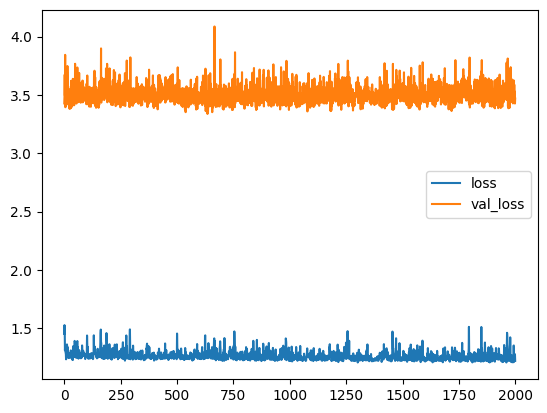

In [469]:
import pandas as pd

pd.DataFrame(history.history)[['loss','val_loss']].plot()

<Axes: >

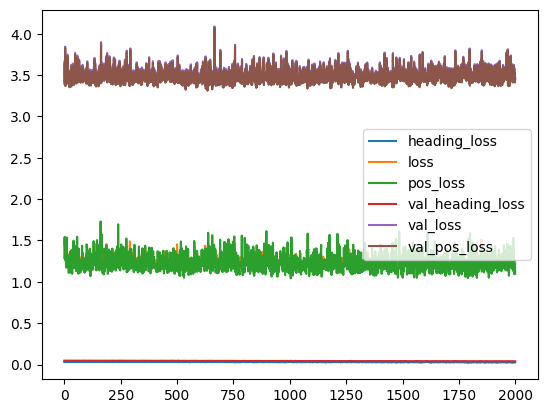

In [470]:
import pandas as pd
pd.DataFrame(history.history).plot()

In [477]:
model.save(MODELS_DIR / 'exp_vive_trained_position.keras')

In [437]:
def preprocess_df(df):
    X = df[['vlp_x_hist','vlp_y_hist', 'encoder_heading_change']].values
    y = df[['x_hist', 'y_hist','heading_hist']].values
    X_win, y_win, m_win = p.window_data(X, y, y, overlap = 0.999999, window_len = 40)
    X_win = np.nan_to_num(p.apply_scaler(X_win), 0.5)
    return X_win, y_win, m_win





In [473]:
df = pd.read_csv(dir / 'exp02_high_acc.csv')
X_win, y_win, m_win = preprocess_df(df)
df = df.iloc[39:]
df.reset_index(drop = True, inplace = True)

pre = model.predict(X_win)

df[['model_x_hist', 'model_y_hist']] =  pre[0]
df['model_heading_hist'] = p.vector_to_ang(pre[1], unit = 'degrees')

model_pos_errs = np.sqrt(np.square(df['x_hist'] - df['model_x_hist']) + np.square(df['y_hist'] - df['model_y_hist']))
vlp_pos_errs = np.sqrt(np.square(df['x_hist'] - df['vlp_x_hist']) + np.square(df['y_hist'] - df['vlp_y_hist']))
encoder_pos_errs = np.sqrt(np.square(df['x_hist'] - df['encoder_x_hist']) + np.square(df['y_hist'] - df['encoder_y_hist']))

model_heading_err = [c.normalize_angle(a) for a in (df['heading_hist'] - df['model_heading_hist'])]
encoder_heading_err = [c.normalize_angle(a) for a in (df['heading_hist'] - df['encoder_heading_hist'])]
vlp_heading_err = [c.normalize_angle(a) for a in (df['heading_hist'] - df['vlp_heading_hist'])]

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


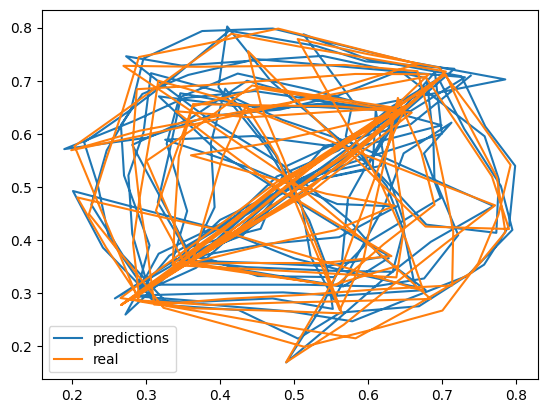

In [474]:
plt.plot(df['model_x_hist'], df['model_y_hist'], label = 'predictions')
plt.plot(df['x_hist'], df['y_hist'], label = 'real')
# plt.plot(df['vlp_x_hist'], df['vlp_y_hist'])


plt.legend()

model mean err:  0.02055293796954114
vlp mean err:  0.032815499507939376
encoder mean err:  0.26962430285700895


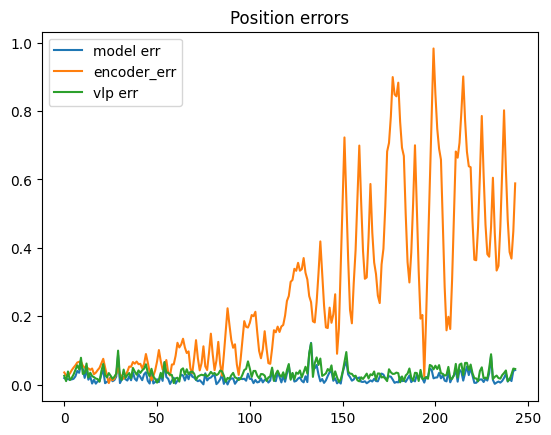

In [475]:
plt.plot(model_pos_errs, label = 'model err')
plt.plot(encoder_pos_errs, label = 'encoder_err')
plt.plot(vlp_pos_errs, label = 'vlp err')
plt.legend()
plt.title('Position errors')
print('model mean err: ', np.mean(model_pos_errs))
print('vlp mean err: ', np.mean(vlp_pos_errs))
print('encoder mean err: ', np.mean(encoder_pos_errs))

mod_heading_err :  12.00227251216815
enc_heading_err:  82.6083510795824
vlp_heading_err:  9.725149916375273


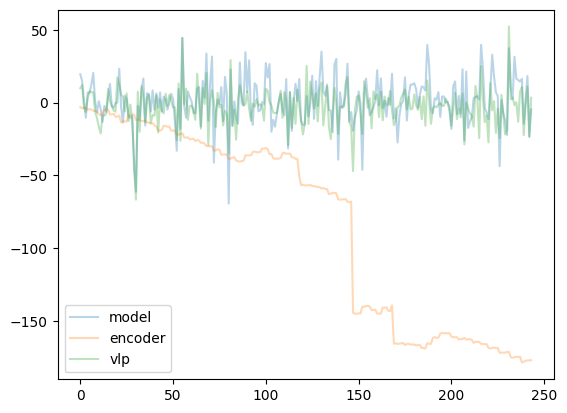

In [476]:


plt.plot(model_heading_err, label = 'model', alpha = 0.3)
plt.plot(encoder_heading_err, label = 'encoder', alpha = 0.3)
plt.plot(vlp_heading_err, label = 'vlp', alpha = 0.3)
plt.legend()

print('mod_heading_err : ', np.mean(np.abs(model_heading_err )))
print('enc_heading_err: ', np.mean(np.abs(encoder_heading_err)))
print('vlp_heading_err: ', np.mean(np.abs(vlp_heading_err)))

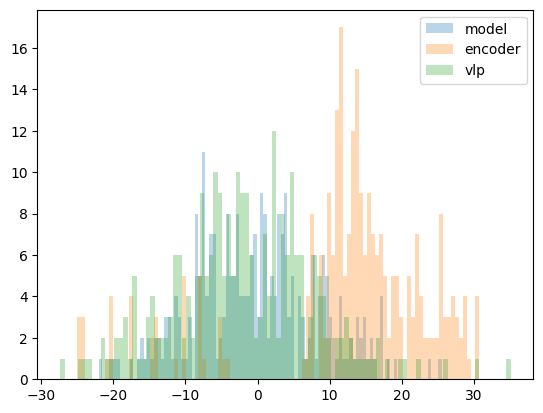

In [363]:
_ = plt.hist(model_heading_err, alpha = 0.3, bins = 100, label = 'model')
_ = plt.hist(encoder_heading_err, alpha = 0.3, bins = 100, label = 'encoder')
_ = plt.hist(vlp_heading_err, alpha = 0.3, bins = 100, label = 'vlp')
plt.legend()